In [1]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
from tensorflow import keras
import matplotlib.pyplot as plt

### Rename

In [ ]:
import os

def rename_files_in_directory(folder_path, new_name_prefix="Supernova_Remnant"):
    # Get a list of all files in the directory
    files = os.listdir(folder_path)
    
    # Counter to make unique file names
    counter = 1
    
    # Loop through each file in the directory
    for filename in files:
        # Construct the full file path
        file_path = os.path.join(folder_path, filename)
        
        # Check if it's a file (not a directory)
        if os.path.isfile(file_path):
            # Get the file extension
            file_extension = os.path.splitext(filename)[1]
            
            # New file name with the counter appended
            new_name = f"{new_name_prefix}_{counter}{file_extension}"
            new_file_path = os.path.join(folder_path, new_name)
            
            # Rename the file
            os.rename(file_path, new_file_path)
            
            print(f"Renamed '{filename}' to '{new_name}'")
            
            # Increment the counter
            counter += 1

# Specify the path to the directory
folder_directory = r"validation/Supernova Remnant"  # Replace with your folder path

# Call the function to rename files
rename_files_in_directory(folder_directory)


## Import Dataset

In [2]:
batch_size = 32
img_height = 224
img_width = 224

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train/",
    batch_size = batch_size,
    image_size = (img_height, img_width)
)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    "validation/",
    batch_size = batch_size,
    image_size = (img_height, img_width)
)

Found 1231 files belonging to 5 classes.
Found 290 files belonging to 5 classes.


In [4]:
class_names = train_ds.class_names
class_names_2 = validation_ds.class_names
print(class_names)
print(class_names_2)

['Dark Nebula', 'Emission Nebula', 'Planetary Nebula', 'Reflection Nebula', 'Supernova Remnants']
['Dark Nebula', 'Emission Nebula', 'Planetary Nebula', 'Reflection Nebula', 'Supernova Remnant']


### Fix datatype

In [5]:
import os
from PIL import Image

def convert_images_to_jpg(directory_path):
    # Ensure the provided directory exists
    if not os.path.isdir(directory_path):
        print("The specified directory does not exist.")
        return

    # Iterate over each file in the directory
    for filename in os.listdir(directory_path):
        file_path = os.path.join(directory_path, filename)

        # Process only if it's a file (not a directory) and not already in RGB format
        if os.path.isfile(file_path):
            try:
                # Open the image file
                with Image.open(file_path) as img:
                    # Convert to RGB mode (necessary for JPEG)
                    img = img.convert("RGB")

                    # Define new file path with .jpg extension
                    new_file_path = os.path.join(directory_path, os.path.splitext(filename)[0] + ".jpg")

                    # Save the image as JPEG, overwriting if necessary
                    img.save(new_file_path, "JPEG")
                    print(f"Converted and saved {filename} to {new_file_path}")

            except Exception as e:
                print(f"Failed to convert {filename}: {e}")

# Specify the directory containing the images to convert
directory_path = r"validation/Supernova Remnant"
convert_images_to_jpg(directory_path)


Converted and saved Supernova_Remnant_1.jpg to validation/Supernova Remnant\Supernova_Remnant_1.jpg
Converted and saved Supernova_Remnant_10.jpg to validation/Supernova Remnant\Supernova_Remnant_10.jpg
Converted and saved Supernova_Remnant_11.jpg to validation/Supernova Remnant\Supernova_Remnant_11.jpg
Converted and saved Supernova_Remnant_12.jpg to validation/Supernova Remnant\Supernova_Remnant_12.jpg
Converted and saved Supernova_Remnant_13.jpg to validation/Supernova Remnant\Supernova_Remnant_13.jpg
Converted and saved Supernova_Remnant_14.jpg to validation/Supernova Remnant\Supernova_Remnant_14.jpg
Converted and saved Supernova_Remnant_15.jpg to validation/Supernova Remnant\Supernova_Remnant_15.jpg
Converted and saved Supernova_Remnant_16.jpg to validation/Supernova Remnant\Supernova_Remnant_16.jpg
Converted and saved Supernova_Remnant_17.jpg to validation/Supernova Remnant\Supernova_Remnant_17.jpg
Converted and saved Supernova_Remnant_18.jpg to validation/Supernova Remnant\Superno

### Check datatype thank stackoverflow

In [5]:
from pathlib import Path
import imghdr

data_dir = r"validation/Supernova Remnant"
image_extensions = [".png", ".jpg"]  # add there all your images file extensions

img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]
for filepath in Path(data_dir).rglob("*"):
    if filepath.suffix.lower() in image_extensions:
        img_type = imghdr.what(filepath)
        if img_type is None:
            print(f"{filepath} is not an image")
        elif img_type not in img_type_accepted_by_tf:
            print(f"{filepath} is a {img_type}, not accepted by TensorFlow")

C:\Users\User\AppData\Local\Temp\ipykernel_16820\3168820533.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


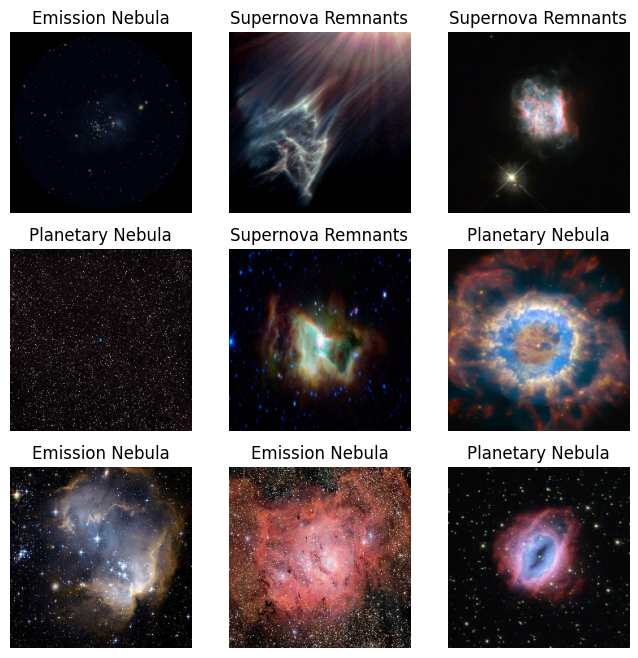

In [5]:
class_names = train_ds.class_names

import matplotlib.pyplot as plt
try:
    plt.figure(figsize=(8, 8))
    for images, labels in validation_ds.take(1):
        for i in range(9):  # Display max 
            ax = plt.subplot(3, 3, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i].numpy()])
            plt.axis("off")
    plt.show()
except tf.errors.InvalidArgumentError as e:
    print("Error loading images from validation dataset:", e)
except Exception as e:
    print("An error occurred:", e)

In [6]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape) 
  print(labels_batch.shape)
  break
#Meaning:
#1 batch = 32 imgages, height, width = 224 and have 3 colors (RGB)

(32, 224, 224, 3)
(32,)


In [7]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Scale to [0, 1]
    return image, label

train_ds = train_ds.map(normalize)
val_ds = validation_ds.map(normalize)


In [8]:
image_batch, labels_batch = next(iter(train_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


# Train

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras import layers, models

In [22]:
num_classes = len(class_names)

model = tf.keras. Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes, activation='softmax')
])



d:\ai_work\Nebulae\nebula\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.add(keras.layers.Activation('softmax'))

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,789,061 (10.64 MB)

 Trainable params: 2,789,061 (10.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [19]:
callbacks = [
    ModelCheckpoint("so_back.keras", save_best_only=True, monitor='val_accuracy', mode='max'),
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
]

In [21]:
epochs = 80
batch_size = 32
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs,
    batch_size = batch_size,
    callbacks = callbacks
)

Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 251ms/step - accuracy: 0.5922 - loss: 1.1330 - val_accuracy: 0.4172 - val_loss: 40.3890
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.5947 - loss: 1.1176 - val_accuracy: 0.4241 - val_loss: 75.9562
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.6327 - loss: 1.0748 - val_accuracy: 0.5586 - val_loss: 79.7854
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.6191 - loss: 1.0615 - val_accuracy: 0.5586 - val_loss: 137.5060
Epoch 5/80
 9/39 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.6960 - loss: 0.9082

KeyboardInterrupt: 

# Evaluation

In [118]:
import pandas as pd

In [120]:
metrics = pd.DataFrame(model.history)
metrics

AttributeError: 'Sequential' object has no attribute 'history'

In [30]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('Best_model.keras')  # Replace with the path to your saved model file


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


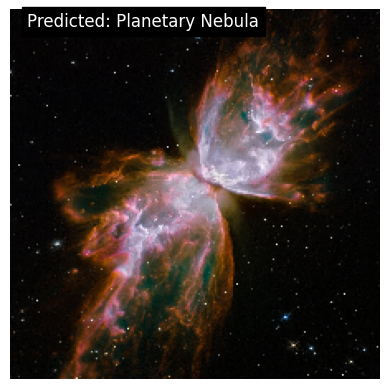

In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = 'wrr.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0
# Make a prediction
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions)

class_names = class_names
predicted_class_name = class_names[predicted_class]


plt.imshow(img)
plt.axis('off')


plt.text(10, 10, f'Predicted: {predicted_class_name}', fontsize=12, color='white', backgroundcolor='black')

plt.show()
